In [99]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib import cm
from scipy.ndimage import gaussian_filter
import pandas as pd
import colormaps as cmaps
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Set matplotlib defaults for better-looking plots
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Configuration

Set the model source to compare against ERA5, along with hemisphere and overlap category.

In [100]:
# Configuration
model_source = "casesm2_10km_nocumulus"  # Options: 'scream', 'nicam_gl11', 'icon_d3hp003', 'um_glm_n2560_RAL3p3'
reference_source = "era5"  # Reference dataset
hemisphere = "nh"  # Options: 'nh' (Northern Hemisphere), 'sh' (Southern Hemisphere)
overlap_type = "3way"  # Options: 'isolated', 'mcs_only', 'ar_only', '3way'

source_map = {
    "scream": "SCREAM",
    "era5": "ERA5",
    "nicam_gl11": "NICAM",
    "icon_d3hp003": "ICON",
    "um_glm_n2560_RAL3p3": "UM",
    "casesm2_10km_nocumulus": "CASESM2",
}

# Data paths
data_dir_base = "/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/"

# Figure output directory
figdir = f"/global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/differences/"
os.makedirs(figdir, exist_ok=True)

print(f"Model: {source_map[model_source]}")
print(f"Reference: {source_map[reference_source]}")
print(f"Hemisphere: {hemisphere.upper()}")
print(f"Overlap type: {overlap_type}")

Model: CASESM2
Reference: ERA5
Hemisphere: NH
Overlap type: 3way


## 2. Load Composite Data

Load both model and ERA5 composite datasets.

In [101]:
# Load model composite
model_file = f"{data_dir_base}{model_source}/etc_2d_composite_{hemisphere}_{overlap_type}.nc"
print(f"Loading model data: {model_file}")
ds_model = xr.open_dataset(model_file)

# Load ERA5 reference composite
reference_file = f"{data_dir_base}{reference_source}/etc_2d_composite_{hemisphere}_{overlap_type}.nc"
print(f"Loading reference data: {reference_file}")
ds_ref = xr.open_dataset(reference_file)

print(f"\nModel dataset loaded: {len(ds_model.y)} × {len(ds_model.x)}")
print(f"Reference dataset loaded: {len(ds_ref.y)} × {len(ds_ref.x)}")

# Check coordinate compatibility
print(f"\nModel grid: y={ds_model.y.values[0]} to {ds_model.y.values[-1]}, x={ds_model.x.values[0]} to {ds_model.x.values[-1]}")
print(f"Reference grid: y={ds_ref.y.values[0]} to {ds_ref.y.values[-1]}, x={ds_ref.x.values[0]} to {ds_ref.x.values[-1]}")

Loading model data: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/casesm2_10km_nocumulus/etc_2d_composite_nh_3way.nc
Loading reference data: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/era5/etc_2d_composite_nh_3way.nc

Model dataset loaded: 161 × 161
Reference dataset loaded: 161 × 161

Model grid: y=-80 to 80, x=-80 to 80
Reference grid: y=-80 to 80, x=-80 to 80


## 3. Compute Differences

Calculate differences for common variables:
- `hus_850hPa`: Specific humidity at 850 hPa
- `pr`: Precipitation
- `zg_500hPa`: Geopotential height at 500 hPa
- `ar_freq`: AR frequency
- `mcs_freq`: MCS frequency
- `ua_850hPa`, `va_850hPa`: Wind components at 850 hPa
- `qu_850hPa`, `qv_850hPa`: Water vapor flux at 850 hPa

## 3a. Compute Moisture Flux

Compute moisture flux for both model and reference datasets before calculating differences.

In [102]:
# Compute moisture flux for model dataset
if 'hus_850hPa' in ds_model and 'ua_850hPa' in ds_model and 'va_850hPa' in ds_model:
    hus_kgkg_model = ds_model.hus_850hPa / 1000.0
    ds_model['qu_850hPa'] = ds_model.ua_850hPa * hus_kgkg_model
    ds_model['qv_850hPa'] = ds_model.va_850hPa * hus_kgkg_model
    # Convert precipitation from mm/h to mm/day
    ds_model['pr'] = ds_model['pr'] * 24.0
    ds_model['pr_mcs'] = ds_model['pr_mcs'] * 24.0
    ds_model['pr_ar'] = ds_model['pr_ar'] * 24.0
    
    ds_model['qu_850hPa'].attrs = {
        'long_name': 'Eastward moisture flux at 850 hPa',
        'units': 'm/s',
        'description': 'u-component of wind multiplied by specific humidity (u*q)'
    }
    ds_model['qv_850hPa'].attrs = {
        'long_name': 'Northward moisture flux at 850 hPa',
        'units': 'm/s',
        'description': 'v-component of wind multiplied by specific humidity (v*q)'
    }
    print(f"Model moisture flux computed: qu_850hPa, qv_850hPa")

# Compute moisture flux for reference dataset
if 'hus_850hPa' in ds_ref and 'ua_850hPa' in ds_ref and 'va_850hPa' in ds_ref:
    hus_kgkg_ref = ds_ref.hus_850hPa / 1000.0
    ds_ref['qu_850hPa'] = ds_ref.ua_850hPa * hus_kgkg_ref
    ds_ref['qv_850hPa'] = ds_ref.va_850hPa * hus_kgkg_ref
    # Convert precipitation from mm/h to mm/day
    ds_ref['pr'] = ds_ref['pr'] * 24.0
    ds_ref['pr_mcs'] = ds_ref['pr_mcs'] * 24.0
    ds_ref['pr_ar'] = ds_ref['pr_ar'] * 24.0
    
    ds_ref['qu_850hPa'].attrs = {
        'long_name': 'Eastward moisture flux at 850 hPa',
        'units': 'm/s',
        'description': 'u-component of wind multiplied by specific humidity (u*q)'
    }
    ds_ref['qv_850hPa'].attrs = {
        'long_name': 'Northward moisture flux at 850 hPa',
        'units': 'm/s',
        'description': 'v-component of wind multiplied by specific humidity (v*q)'
    }
    print(f"Reference moisture flux computed: qu_850hPa, qv_850hPa")

Model moisture flux computed: qu_850hPa, qv_850hPa
Reference moisture flux computed: qu_850hPa, qv_850hPa


In [103]:
# List of common variables to compute differences for
common_vars = ['hus_850hPa', 'pr', 'zg_500hPa', 'ar_freq', 'mcs_freq', 'ua_850hPa', 'va_850hPa',
               'omega_500hPa', 'pr_mcs', 'pr_ar', 'qu_850hPa', 'qv_850hPa']

# Create a new dataset for differences
ds_diff = xr.Dataset()

# Copy coordinates from model dataset
ds_diff['x'] = ds_model['x']
ds_diff['y'] = ds_model['y']

# Copy attributes
ds_diff.attrs = ds_model.attrs.copy()
ds_diff.attrs['description'] = f'Differences: {source_map[model_source]} - {source_map[reference_source]}'

print("Computing differences for common variables:")
for var in common_vars:
    if var in ds_model and var in ds_ref:
        # Compute difference: model - reference
        ds_diff[var] = ds_model[var] - ds_ref[var]
        
        # Copy attributes
        ds_diff[var].attrs = ds_model[var].attrs.copy()
        ds_diff[var].attrs['long_name'] = f"Difference in {ds_model[var].attrs.get('long_name', var)}"
        
        # Print statistics
        diff_mean = float(ds_diff[var].mean())
        diff_std = float(ds_diff[var].std())
        diff_min = float(ds_diff[var].min())
        diff_max = float(ds_diff[var].max())
        
        print(f"  {var}: mean={diff_mean:.4f}, std={diff_std:.4f}, range=[{diff_min:.4f}, {diff_max:.4f}]")
    else:
        print(f"  {var}: NOT FOUND in one or both datasets")

print(f"\nDifference dataset created with {len(ds_diff.data_vars)} variables")

Computing differences for common variables:
  hus_850hPa: mean=-0.8512, std=0.2896, range=[-1.6879, -0.0973]
  pr: mean=0.2621, std=1.2698, range=[-6.6291, 5.3882]
  zg_500hPa: mean=-98.2373, std=31.0131, range=[-153.7373, -55.4419]
  ar_freq: mean=-0.0130, std=0.0299, range=[-0.1177, 0.1785]
  mcs_freq: mean=-0.0311, std=0.0361, range=[-0.2057, 0.0387]
  ua_850hPa: mean=0.4989, std=0.7412, range=[-1.5316, 3.9628]
  va_850hPa: mean=-0.0381, std=0.8204, range=[-4.3963, 2.8742]
  omega_500hPa: mean=-0.0042, std=0.0794, range=[-0.3022, 0.3167]
  pr_mcs: mean=-0.2775, std=0.6137, range=[-5.9325, 2.2910]
  pr_ar: mean=0.2533, std=0.6856, range=[-1.2583, 4.2322]
  qu_850hPa: mean=-0.0015, std=0.0059, range=[-0.0209, 0.0247]
  qv_850hPa: mean=0.0001, std=0.0032, range=[-0.0345, 0.0118]

Difference dataset created with 12 variables


## 4. Plotting Function

Use the same plotting function from the original notebook.

In [104]:
def plot_etc_composite(ds, 
                       shade_var='hus_850hPa', shade_levels=None, shade_cmap='GnBu', 
                       shade_scale=1.0, shade_alpha=1.0, shade_label=None, cbar_ticks=None,
                       shade_var2=None, shade_levels2=None, shade_cmap2='YlGnBu', 
                       shade_scale2=1.0, shade_alpha2=0.9, shade_label2=None, cbar_ticks2=None,
                       shade_levels2_thresh=None, shade_smooth2=0,
                       contour_var='zg_500hPa', contour_levels=None, contour_smooth=2, contour_lw=3.0,
                       contour_var2=None, contour_levels2=None, contour_cmap2=None, contour_color2=None,
                       contour_smooth2=0, contour_lw2=2.0, contour_var2_legend=None,
                       contour_var3=None, contour_levels3=None, contour_cmap3=None, contour_color3=None,
                       contour_smooth3=0, contour_lw3=2.0, contour_var3_legend=None,
                       u_var='ua_850hPa', v_var='va_850hPa', vector_skip=6,
                       quiverkey_length=10, quiverkey_unit=' m/s', quiver_scale=300,
                       circle_radius=None,
                       xlim=None, ylim=None,
                       xlabel='Longitude offset (°)', ylabel='Latitude offset (°)',
                       title=None,
                       figsize=(12, 10), dpi=200, figname=None,
                       main_width_ratios=None, main_wspace=None,
                       cbar_width_ratios=None, cbar_wspace=None):
    """
    Plot composite ETC data with multiple overlays.
    
    [Full docstring same as original - parameters and descriptions]
    """
    
    # Get coordinates and convert to degrees
    lat_res = ds.attrs.get('lat_res', 0.25)
    lon_res = ds.attrs.get('lon_res', 0.25)
    
    x = ds.x.values * lon_res
    y = ds.y.values * lat_res
    X, Y = np.meshgrid(x, y)
    
    # Create figure with GridSpec for better colorbar control
    fig = plt.figure(figsize=figsize, dpi=dpi)

    contour_fontsize = 10
    
    # Determine number of colorbars needed
    has_shade_var2 = shade_var2 is not None and shade_var2 in ds
    
    if has_shade_var2:
        # Set defaults for 2 colorbars case
        if main_width_ratios is None:
            main_width_ratios = [1, 0.2]
        if main_wspace is None:
            main_wspace = 0.03
        if cbar_width_ratios is None:
            cbar_width_ratios = [0.005, 0.005]
        if cbar_wspace is None:
            cbar_wspace = 4
            
        # Create main GridSpec: [plot | colorbars]
        gs_main = gridspec.GridSpec(1, 2, figure=fig, 
                                   width_ratios=main_width_ratios,
                                   wspace=main_wspace)
        
        ax = fig.add_subplot(gs_main[0])
        
        # Create nested GridSpec for the two colorbars
        gs_cbar = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                                   width_ratios=cbar_width_ratios,
                                                   wspace=cbar_wspace)
        cax1 = fig.add_subplot(gs_cbar[0])
        cax2 = fig.add_subplot(gs_cbar[1])
    else:
        # Set defaults for 1 colorbar case
        if main_width_ratios is None:
            main_width_ratios = [1, 0.04]
        if main_wspace is None:
            main_wspace = 0.02
            
        # Create GridSpec: [main plot | cbar1]
        gs_main = gridspec.GridSpec(1, 2, figure=fig,
                                   width_ratios=main_width_ratios,
                                   wspace=main_wspace)
        ax = fig.add_subplot(gs_main[0])
        cax1 = fig.add_subplot(gs_main[1])
        cax2 = None
    
    # ===== 1. PRIMARY SHADED VARIABLE (z_order=0) =====
    if shade_var in ds:
        shade_data = ds[shade_var].values * shade_scale
        
        if shade_levels is None:
            vmin, vmax = np.nanpercentile(shade_data, [2, 98])
            shade_levels = np.linspace(vmin, vmax, 20)
        
        cf = ax.contourf(X, Y, shade_data, levels=shade_levels,
                        cmap=shade_cmap, extend='both', alpha=shade_alpha, 
                        antialiased=True, zorder=0)
        cbar = plt.colorbar(cf, cax=cax1, orientation='vertical')
        
        if shade_label is not None:
            cbar_label = shade_label
        else:
            cbar_label = f'{shade_var}'
            if shade_scale != 1.0:
                cbar_label += f' (×{shade_scale})'
        cbar.set_label(cbar_label)
        
        # Set custom ticks if provided
        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)
    
    # ===== 2. SECOND SHADED VARIABLE (OVERLAY) (z_order=1) =====
    if shade_var2 is not None and shade_var2 in ds:
        shade_data2 = ds[shade_var2].values * shade_scale2
        
        # Apply smoothing if requested
        if shade_smooth2 > 0:
            shade_data2 = gaussian_filter(shade_data2, sigma=shade_smooth2)
        
        if shade_levels2 is None:
            vmin2, vmax2 = np.nanpercentile(shade_data2[~np.isnan(shade_data2)], [2, 98])
            shade_levels2 = np.linspace(vmin2, vmax2, 20)
        
        # Mask values below threshold if specified (for difference plots)
        if shade_levels2_thresh is not None:
            shade_data2 = np.ma.masked_where(np.abs(shade_data2) < shade_levels2_thresh, shade_data2)
        else:
            # Mask values < min(shade_levels2) (original behavior)
            shade_data2 = np.ma.masked_where(shade_data2 < np.min(shade_levels2), shade_data2)
        
        cf2 = ax.contourf(X, Y, shade_data2, levels=shade_levels2,
                         cmap=shade_cmap2, extend='both', alpha=shade_alpha2,
                         antialiased=True, zorder=1)
        
        if cax2 is not None:
            cbar2 = plt.colorbar(cf2, cax=cax2, orientation='vertical')
            
            if shade_label2 is not None:
                cbar_label2 = shade_label2
            else:
                cbar_label2 = f'{shade_var2}'
                if shade_scale2 != 1.0:
                    cbar_label2 += f' (×{shade_scale2})'
            cbar2.set_label(cbar_label2)
            
            # Set custom ticks if provided
            if cbar_ticks2 is not None:
                cbar2.set_ticks(cbar_ticks2)
    
    # ===== 3. LINE CONTOUR VARIABLE (z_order=2) =====
    if contour_var in ds:
        contour_data = ds[contour_var].values
        
        # Apply smoothing if requested
        if contour_smooth > 0:
            contour_data = gaussian_filter(contour_data, sigma=contour_smooth)
        
        if contour_levels is None:
            vmin, vmax = np.nanpercentile(contour_data, [5, 95])
            contour_levels = np.linspace(vmin, vmax, 10)
        
        cs = ax.contour(X, Y, contour_data, levels=contour_levels, 
                       colors='black', linewidths=contour_lw, alpha=0.6, zorder=2)
        ax.clabel(cs, inline=True, fontsize=contour_fontsize, fmt='%.0f')
    
    # ===== 4. SECOND CONTOUR VARIABLE (LINE) (z_order=3) =====
    if contour_var2 is not None and contour_var2 in ds:
        contour_data2 = ds[contour_var2].values
        
        # Apply smoothing if requested
        if contour_smooth2 > 0:
            contour_data2 = gaussian_filter(contour_data2, sigma=contour_smooth2)
        
        if contour_levels2 is None:
            vmin2, vmax2 = np.nanpercentile(contour_data2[~np.isnan(contour_data2)], [2, 98])
            contour_levels2 = np.linspace(vmin2, vmax2, 10)
        
        # Determine if using colormap or single color
        if contour_color2 is not None:
            # Single color mode
            cs2 = ax.contour(X, Y, contour_data2, levels=contour_levels2,
                            colors=[contour_color2], linewidths=contour_lw2, zorder=3)
        else:
            # Colormap mode (default to 'Greens' if not specified)
            cmap2 = contour_cmap2 if contour_cmap2 is not None else 'Greens'
            cs2 = ax.contour(X, Y, contour_data2, levels=contour_levels2,
                            cmap=cmap2, linewidths=contour_lw2, zorder=3)
        ax.clabel(cs2, inline=True, fontsize=contour_fontsize, fmt='%.2f')
    
    # ===== 5. THIRD CONTOUR VARIABLE (LINE) (z_order=4) =====
    if contour_var3 is not None and contour_var3 in ds:
        contour_data3 = ds[contour_var3].values

        # Apply smoothing if requested
        if contour_smooth3 > 0:
            contour_data3 = gaussian_filter(contour_data3, sigma=contour_smooth3)
        
        # Determine if using colormap or single color
        if contour_color3 is not None:
            # Single color mode
            cs3 = ax.contour(X, Y, contour_data3, levels=contour_levels3,
                            colors=[contour_color3], linewidths=contour_lw3, zorder=4)
        else:
            # Colormap mode (default to 'Oranges' if not specified)
            cmap3 = contour_cmap3 if contour_cmap3 is not None else 'Oranges'
            cs3 = ax.contour(X, Y, contour_data3, levels=contour_levels3,
                            cmap=cmap3, linewidths=contour_lw3, zorder=4)
        ax.clabel(cs3, inline=True, fontsize=contour_fontsize, fmt='%.2f')
    
    # ===== 6. WIND VECTORS (z_order=5) =====
    if u_var in ds and v_var in ds:
        u_data = ds[u_var].values
        v_data = ds[v_var].values
        
        # Subsample for vector plotting
        X_sub = X[::vector_skip, ::vector_skip]
        Y_sub = Y[::vector_skip, ::vector_skip]
        u_sub = u_data[::vector_skip, ::vector_skip]
        v_sub = v_data[::vector_skip, ::vector_skip]
        
        Q = ax.quiver(X_sub, Y_sub, u_sub, v_sub, 
                     color='black', alpha=0.7, scale=quiver_scale, width=0.0035, zorder=5)
        
        # Format quiverkey label based on magnitude
        if quiverkey_length < 0.1:
            # Use scientific notation for small values (< 0.1)
            exponent = int(np.floor(np.log10(abs(quiverkey_length))))
            mantissa = quiverkey_length / (10 ** exponent)
            if mantissa == 1.0:
                quiver_label = f'$10^{{{exponent}}}${quiverkey_unit}'
            else:
                quiver_label = f'${mantissa:.1f} \\times 10^{{{exponent}}}${quiverkey_unit}'
        elif quiverkey_length < 1.0:
            # Show 1 decimal place for values between 0.1 and 1.0
            quiver_label = f'{quiverkey_length:.1f} {quiverkey_unit}'
        else:
            # Round to integer for values >= 1.0
            quiver_label = f'{int(round(quiverkey_length))} {quiverkey_unit}'
        
        ax.quiverkey(Q, 0.77, 1.02, quiverkey_length, quiver_label, labelpos='E', coordinates='axes')

    # ===== 7. LABELS AND FORMATTING =====
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Title
    if title is not None:
        ax.set_title(title, fontweight='bold')
    
    # Add gridlines
    # ax.grid(True, alpha=0.5, linestyle=':', linewidth=0.5, zorder=10)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder=10)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1, zorder=10)
    
    # Set x, y limits if specified
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # ===== 8. CIRCLE (z_order=6) =====
    if circle_radius is not None:
        circle = plt.Circle((0, 0), circle_radius, fill=False, 
                           edgecolor='purple', linewidth=4, alpha=0.7, zorder=6)
        ax.add_patch(circle)
    
    # ===== 9. LEGEND FOR FREQUENCY CONTOURS =====
    legend_elements = []
    if contour_var2 is not None and contour_var2 in ds:
        # Use custom legend label if provided, otherwise use variable name
        legend_label2 = contour_var2_legend if contour_var2_legend is not None else contour_var2
        
        if contour_color2 is not None:
            # Single color: use that color
            color2 = contour_color2
        else:
            # Colormap: get a representative color from the colormap (middle value)
            cmap2_name = contour_cmap2 if contour_cmap2 is not None else 'Greens'
            cmap2 = mpl.colormaps.get_cmap(cmap2_name)
            color2 = cmap2(0.6)  # Use darker shade for legend
        
        legend_elements.append(Line2D([0], [0], color=color2, linewidth=contour_lw2, 
                                     label=legend_label2))
    
    if contour_var3 is not None and contour_var3 in ds:
        # Use custom legend label if provided, otherwise use variable name
        legend_label3 = contour_var3_legend if contour_var3_legend is not None else contour_var3
        
        if contour_color3 is not None:
            # Single color: use that color
            color3 = contour_color3
        else:
            # Colormap: get a representative color from the colormap (middle value)
            cmap3_name = contour_cmap3 if contour_cmap3 is not None else 'Oranges'
            cmap3 = mpl.colormaps.get_cmap(cmap3_name)
            color3 = cmap3(0.6)  # Use darker shade for legend
        
        legend_elements.append(Line2D([0], [0], color=color3, linewidth=contour_lw3, 
                                     label=legend_label3))
    
    if legend_elements:
        leg = ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
        leg.set_zorder(10)  # Ensure legend is on top of all plot elements
    
    # Save figure if filename is provided
    if figname:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f'Figure saved: {figname}')
    
    return fig

print("Plotting function defined successfully!")

Plotting function defined successfully!


## 5. Plot Differences

Create visualization of the differences between model and ERA5.

In [105]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/differences/etc_composite_diff_nh_hus850_casesm2_10km_nocumulus_minus_era5.png

Difference composite visualization created!
Model: CASESM2
Reference: ERA5
Hemisphere: Northern Hemisphere
Overlap type: ETC + MCS + AR (3-way)


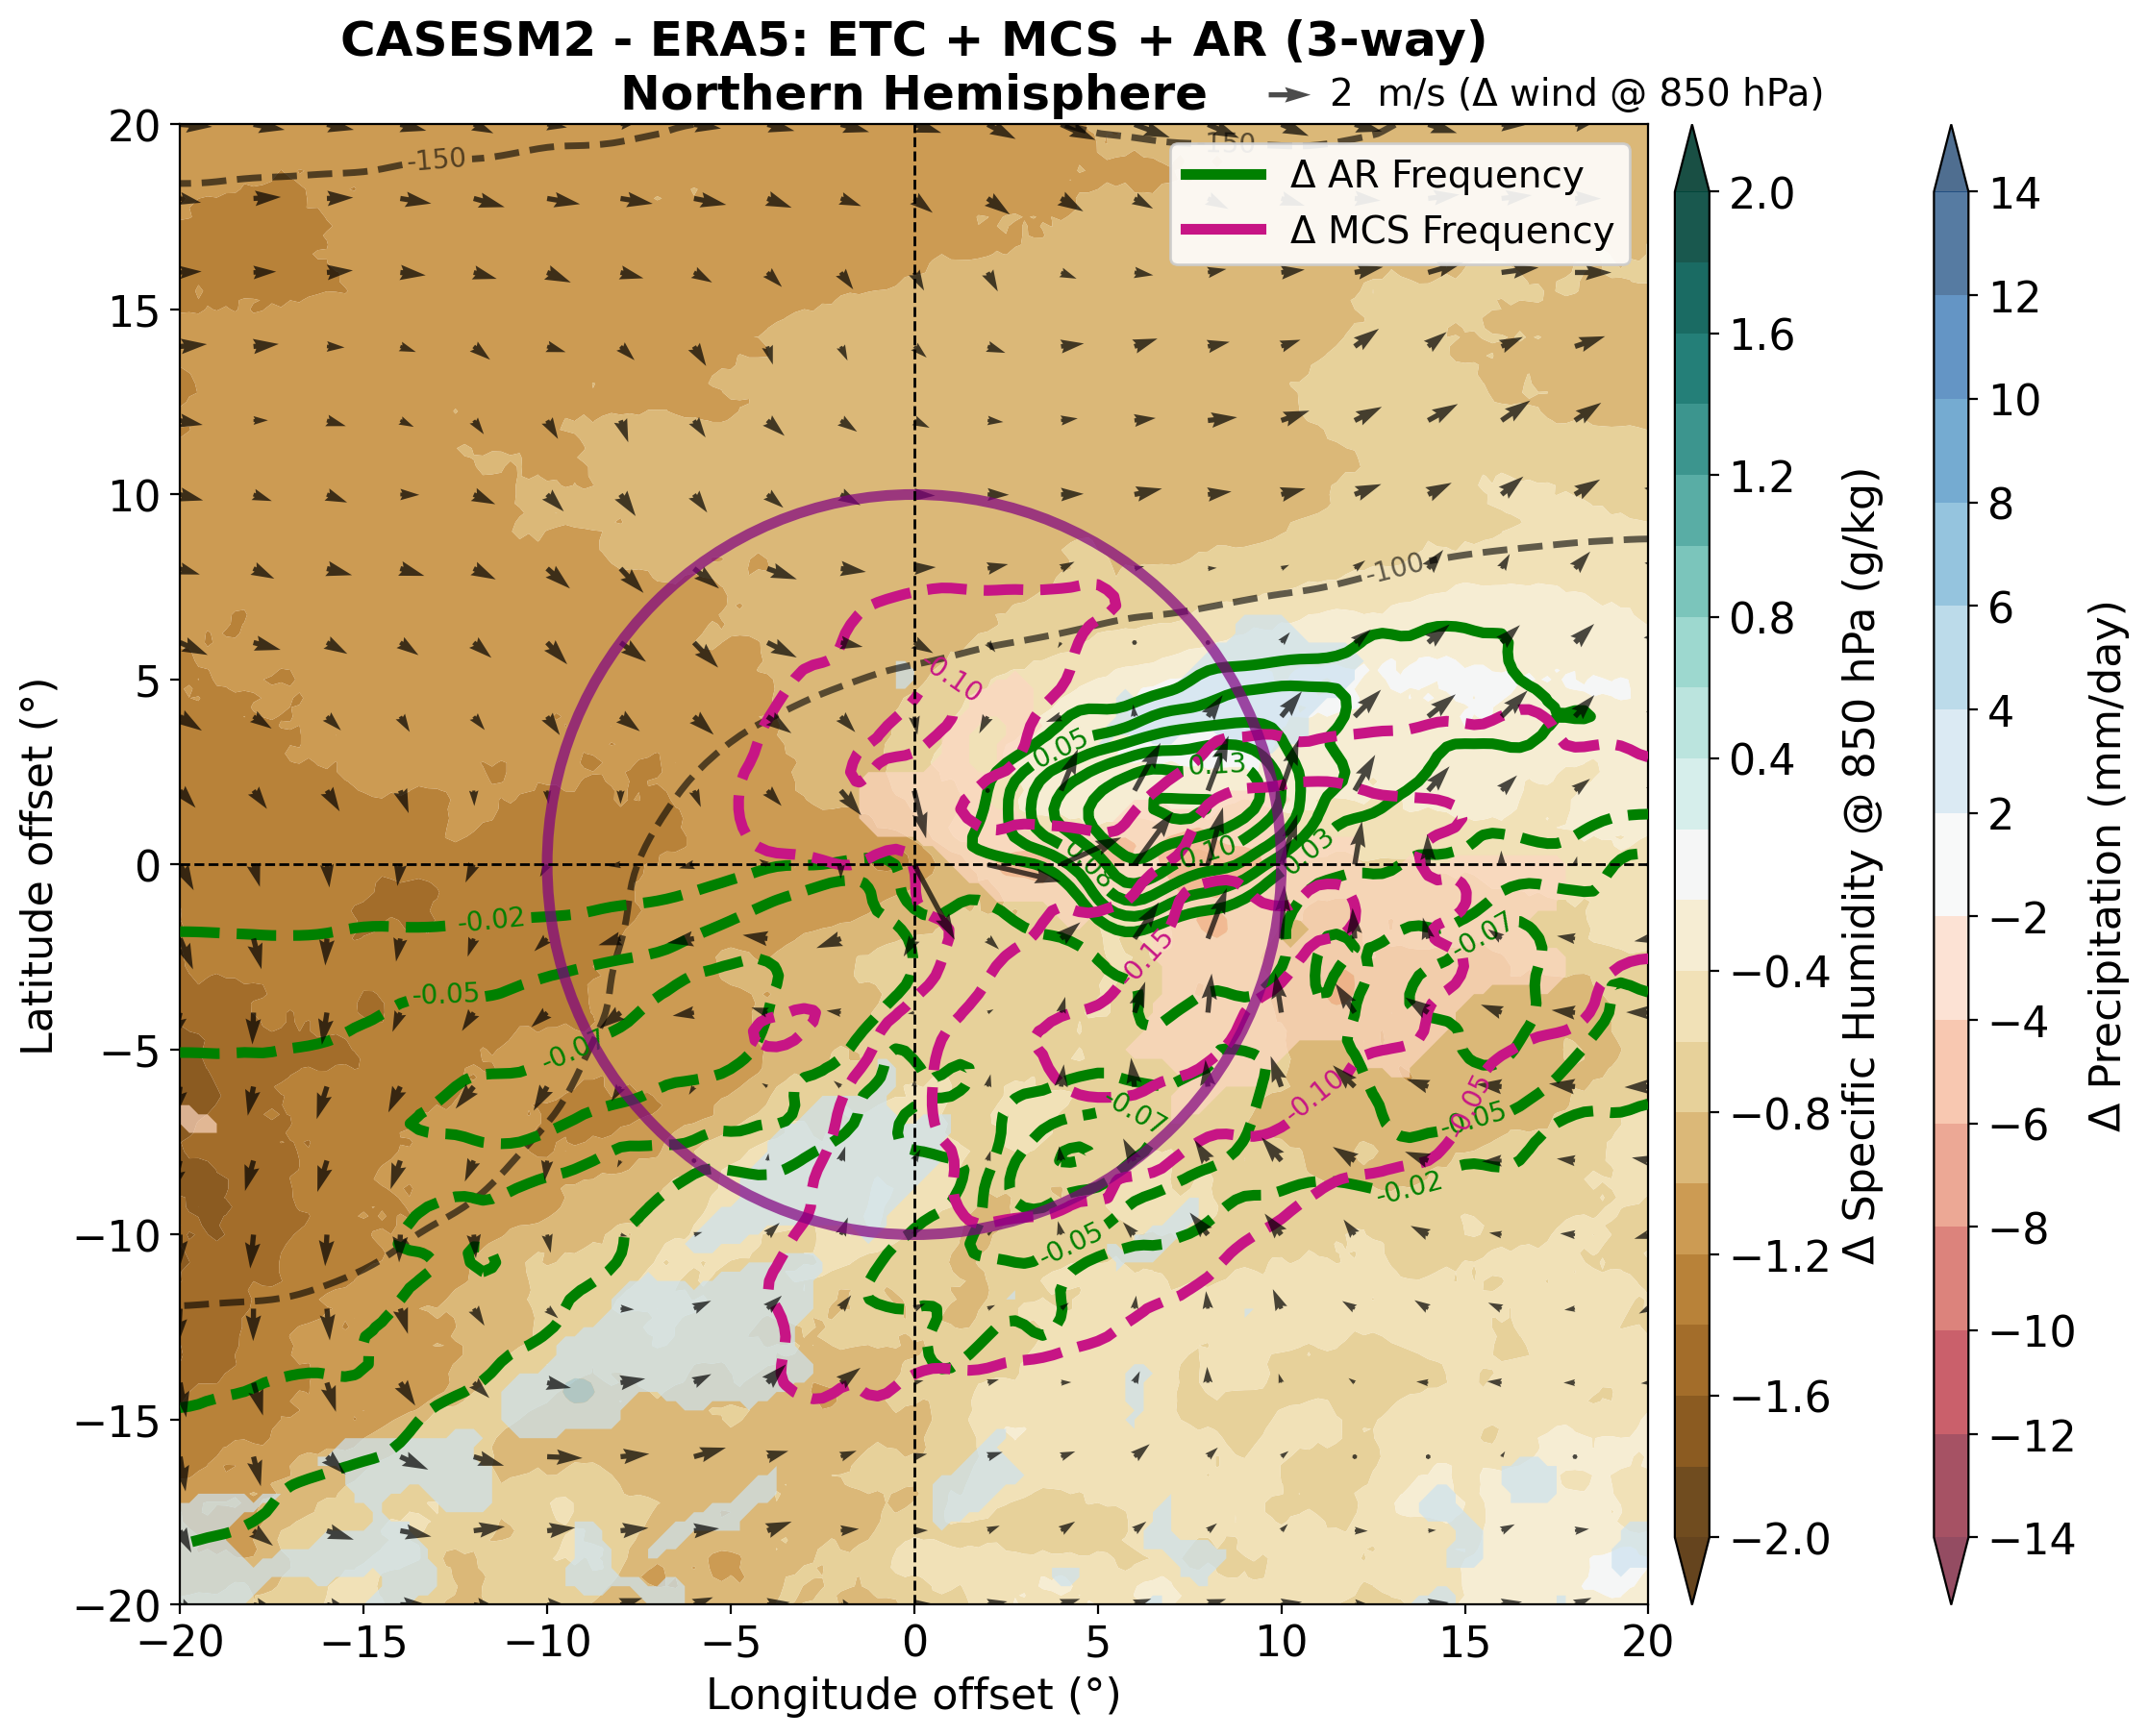

In [106]:
# Generate output filename
figname = f"{figdir}etc_composite_diff_{hemisphere}_hus850_{model_source}_minus_{reference_source}.png"

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC + MCS only',
    'ar_only': 'ETC + AR only',
    '3way': 'ETC + MCS + AR (3-way)'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[model_source]} - {source_map[reference_source]}: {overlap_desc}\n{hemisphere_name}'

# Difference in g/kg for specific humidity
shade_levels = np.array([x for x in np.arange(-2.0, 2.1, 0.2) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-2, 2.1, 0.4) if np.abs(x) > 1e-5])
# Difference in mm/hr for precipitation
# shade_levels2 = np.array([x for x in np.arange(-0.6, 0.61, 0.1) if np.abs(x) > 1e-5])
# cbar_ticks2 = np.array([x for x in np.arange(-0.6, 0.61, 0.1) if np.abs(x) > 1e-5])
# Difference in mm/day for precipitation
shade_levels2 = np.array([x for x in np.arange(-14., 14.1, 2) if np.abs(x) > 1e-3])
cbar_ticks2 = np.array([x for x in np.arange(-14., 14.1, 2) if np.abs(x) > 1e-3])
# Threshold for masking small precipitation differences
shade_levels2_thresh = np.min(np.abs(shade_levels2[shade_levels2 != 0]))

# Remove zero from contour levels to avoid plotting zero lines
contour_levels = np.array([x for x in np.arange(-200, 201, 50) if x != 0])
contour_levels2 = np.array([x for x in np.arange(-0.3, 0.31, 0.025) if np.abs(x) > 1e-5])
contour_levels3 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if np.abs(x) > 1e-5])

cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)

# Create the plot with diverging colormaps for differences
fig = plot_etc_composite(
    ds_diff,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='hus_850hPa',
    shade_levels=shade_levels,  # Difference in g/kg
    cbar_ticks=cbar_ticks,
    shade_alpha=0.9,
    shade_cmap='BrBG',
    shade_label='Δ Specific Humidity @ 850 hPa (g/kg)',
    # Add precipitation difference overlay
    shade_var2='pr',
    shade_levels2=shade_levels2,  # Difference in mm/hr
    cbar_ticks2=cbar_ticks2,
    shade_cmap2='RdBu',
    shade_alpha2=0.7,
    shade_label2='Δ Precipitation (mm/day)',
    shade_levels2_thresh=shade_levels2_thresh,  # Mask differences below this threshold
    shade_smooth2=1.0,  # Smoothing
    # Add 500 hPa geopotential height difference contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels, 
    contour_smooth=2,
    contour_lw=2.5,
    # Add AR frequency difference contours
    contour_var2='ar_freq',
    contour_var2_legend='Δ AR Frequency',
    contour_levels2=contour_levels2,
    # contour_cmap2=cmap_ct2,
    contour_color2='green',
    contour_smooth2=1.5,
    contour_lw2=4,
    # Add MCS frequency difference contours
    contour_var3='mcs_freq',
    contour_var3_legend='Δ MCS Frequency',
    contour_levels3=contour_levels3,
    # contour_cmap3=cmap_ct3,
    contour_color3='mediumvioletred',
    contour_smooth3=1.5,
    contour_lw3=4,
    # Wind difference vectors at 850 hPa
    u_var='ua_850hPa',
    v_var='va_850hPa',
    vector_skip=8,
    quiver_scale=70,
    quiverkey_length=2, 
    quiverkey_unit=' m/s (Δ wind @ 850 hPa)',
    circle_radius=10.0,
    title=title,
    dpi=200,
    figname=figname,
)

print(f"\nDifference composite visualization created!")
print(f"Model: {source_map[model_source]}")
print(f"Reference: {source_map[reference_source]}")
print(f"Hemisphere: {hemisphere_name}")
print(f"Overlap type: {overlap_desc}")

## 5a. Plot MCS-Specific Differences

Visualize differences in MCS contributions: vertical motion, MCS-only precipitation, MCS frequency, and moisture flux.

Figure saved: etc_composite_diff_nh_mcs_casesm2_10km_nocumulus_era5.png


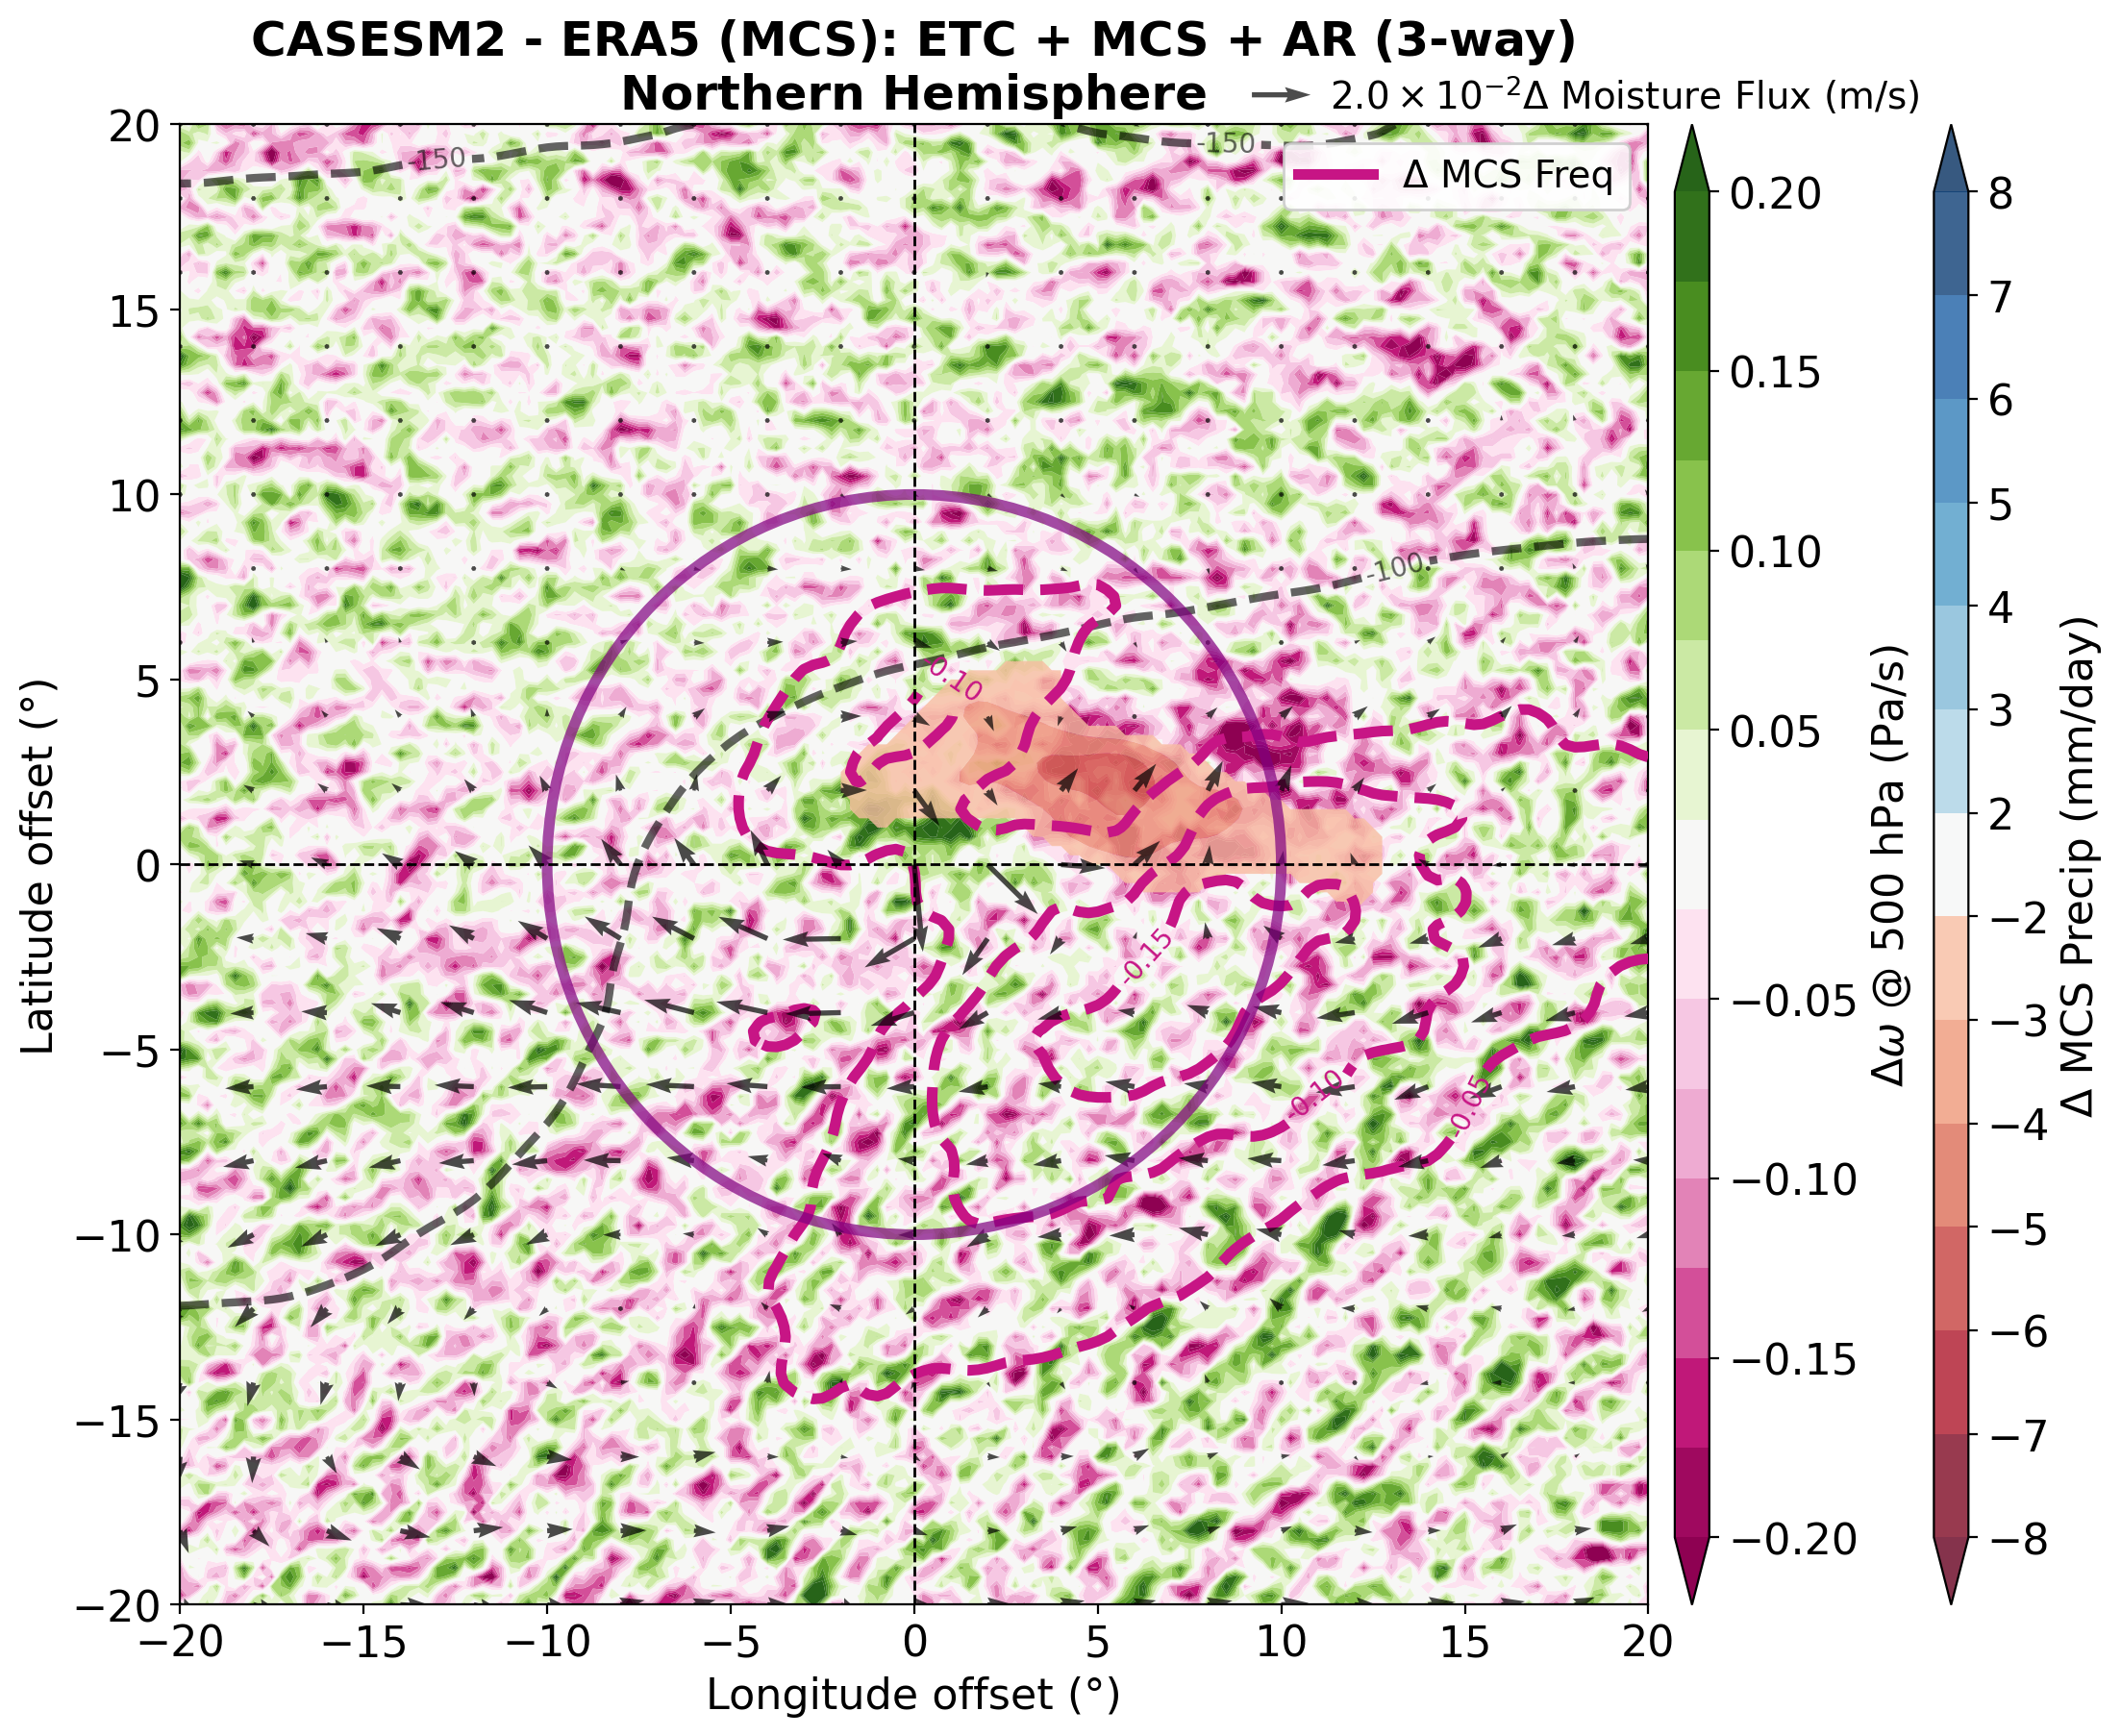

In [107]:
# Plot MCS-specific differences

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC + MCS only',
    'ar_only': 'ETC + AR only',
    '3way': 'ETC + MCS + AR (3-way)'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[model_source]} - {source_map[reference_source]} (MCS): {overlap_desc}\n{hemisphere_name}'

# Difference in omega at 500 hPa
shade_levels = np.array([x for x in np.arange(-0.2, 0.21, 0.025) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-0.2, 0.21, 0.05) if np.abs(x) > 1e-5])
# # Difference in mm/hr for precipitation
# shade_levels2 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if np.abs(x) > 1e-5])
# cbar_ticks2 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if np.abs(x) > 1e-5])
# Difference in mm/day for precipitation
shade_levels2 = np.array([-8,-7,-6,-5,-4,-3,-2,2,3,4,5,6,7,8])
cbar_ticks2 = shade_levels2
# Threshold for masking small precipitation differences
shade_levels2_thresh = np.min(np.abs(shade_levels2[shade_levels2 != 0]))

# Remove zero from contour levels to avoid plotting zero lines
contour_levels = np.array([x for x in np.arange(-200, 201, 50) if x != 0])
contour_levels2 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if np.abs(x) > 1e-5])
contour_levels3 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if np.abs(x) > 1e-5])

cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)

fig = plot_etc_composite(
    ds_diff,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='omega_500hPa',
    shade_levels=shade_levels,
    cbar_ticks=cbar_ticks,
    shade_cmap='PiYG',
    shade_alpha=1.0,
    shade_label='$\\Delta \\omega$ @ 500 hPa (Pa/s)',
    # Add precipitation overlay
    shade_var2='pr_mcs',
    shade_levels2=shade_levels2,
    shade_levels2_thresh=shade_levels2_thresh,
    cbar_ticks2=cbar_ticks2,
    shade_smooth2=2.0,
    shade_alpha2=0.8,
    shade_cmap2='RdBu',
    shade_label2='Δ MCS Precip (mm/day)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # Add MCS frequency contours
    contour_var3='mcs_freq',
    contour_var3_legend='Δ MCS Freq',
    contour_levels3=contour_levels3,
    # contour_cmap3=cmap_ct3,
    contour_color3='mediumvioletred',
    contour_smooth3=1.5,
    contour_lw3=4,
    # Moisture flux vectors at 850 hPa
    u_var='qu_850hPa',
    v_var='qv_850hPa',
    vector_skip=8,
    quiver_scale=0.5,
    quiverkey_length=0.02,
    quiverkey_unit='Δ Moisture Flux (m/s)',
    circle_radius=10.0,
    title=title,
    # dpi=200,
)

# Save figure
figname = f'etc_composite_diff_{hemisphere}_mcs_{model_source}_{reference_source}.png'
fig.savefig(os.path.join(figdir, figname), dpi=200, bbox_inches='tight', facecolor='white')
print(f'Figure saved: {figname}')
plt.show()

## 5b. Plot AR-Specific Differences

Visualize differences in AR contributions: vertical motion, AR-only precipitation, AR frequency, and moisture flux.

Figure saved: etc_composite_diff_nh_ar_casesm2_10km_nocumulus_era5.png


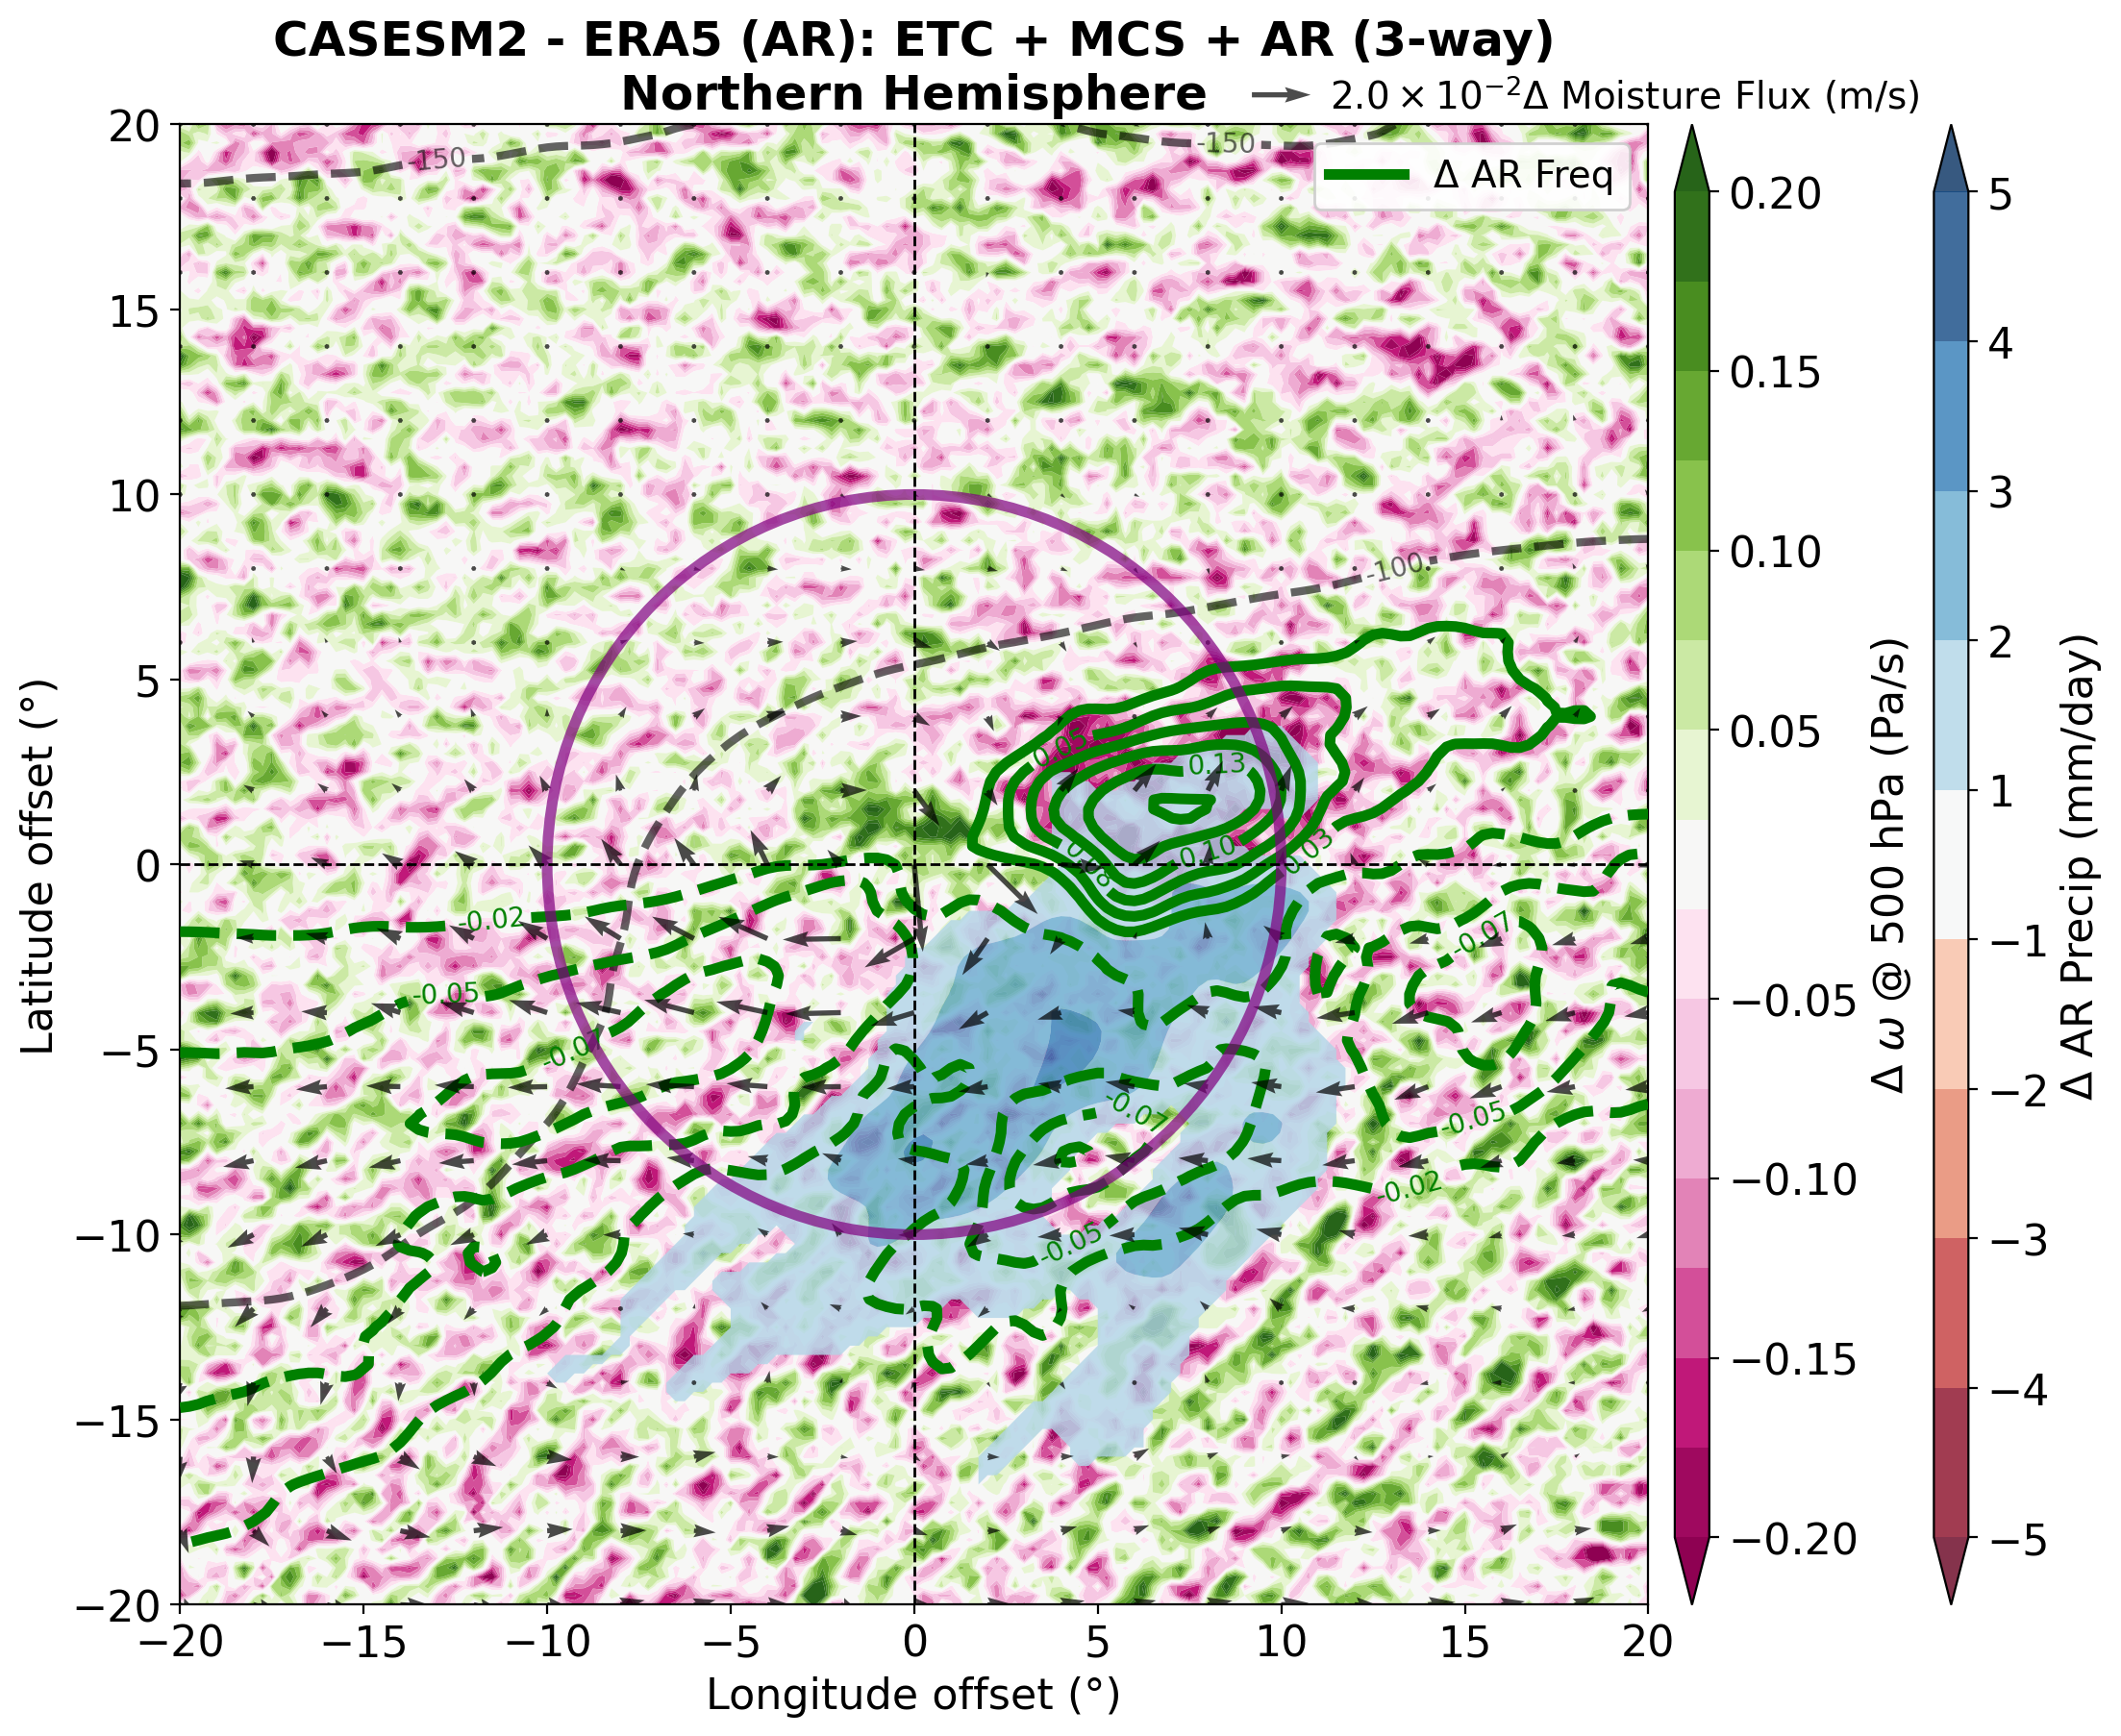

In [108]:
# Plot AR-specific differences

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC + MCS only',
    'ar_only': 'ETC + AR only',
    '3way': 'ETC + MCS + AR (3-way)'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[model_source]} - {source_map[reference_source]} (AR): {overlap_desc}\n{hemisphere_name}'

# Difference in omega at 500 hPa
shade_levels = np.array([x for x in np.arange(-0.2, 0.21, 0.025) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-0.2, 0.21, 0.05) if np.abs(x) > 1e-5])
# Difference in mm/hr for precipitation
# shade_levels2 = np.array([x for x in np.arange(-0.2, 0.21, 0.02) if np.abs(x) > 1e-5])
# cbar_ticks2 = np.array([x for x in np.arange(-0.2, 0.21, 0.04) if np.abs(x) > 1e-5])
# Difference in mm/day for precipitation
shade_levels2 = np.array([-5,-4,-3,-2,-1,1,2,3,4,5])
cbar_ticks2 = shade_levels2
# Threshold for masking small precipitation differences
shade_levels2_thresh = np.min(np.abs(shade_levels2[shade_levels2 != 0]))

# Remove zero from contour levels to avoid plotting zero lines
contour_levels = np.array([x for x in np.arange(-200, 201, 50) if x != 0])
contour_levels2 = np.array([x for x in np.arange(-0.3, 0.31, 0.025) if np.abs(x) > 1e-5])
# contour_levels3 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if np.abs(x) > 1e-5])

cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)

fig = plot_etc_composite(
    ds_diff,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='omega_500hPa',
    shade_levels=shade_levels,
    cbar_ticks=cbar_ticks,
    shade_cmap='PiYG',
    shade_alpha=1.0,
    shade_label='Δ $\\omega$ @ 500 hPa (Pa/s)',
    # Add precipitation overlay
    shade_var2='pr_ar',
    shade_levels2=shade_levels2,
    shade_levels2_thresh=shade_levels2_thresh,
    cbar_ticks2=cbar_ticks2,
    shade_smooth2=2.0,
    shade_alpha2=0.8,
    shade_cmap2='RdBu',
    shade_label2='Δ AR Precip (mm/day)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # Add AR frequency contours
    contour_var2='ar_freq',
    contour_var2_legend='Δ AR Freq',
    contour_levels2=contour_levels2,
    # contour_cmap2=cmap_ct2,
    contour_color2='green',
    contour_smooth2=1.5,
    contour_lw2=4,
    # Moisture flux vectors at 850 hPa
    u_var='qu_850hPa',
    v_var='qv_850hPa',
    vector_skip=8,
    quiver_scale=0.5,
    quiverkey_length=0.02,
    quiverkey_unit='Δ Moisture Flux (m/s)',
    circle_radius=10.0,
    title=title,
    # dpi=200,
)

# Save figure
figname = f'etc_composite_diff_{hemisphere}_ar_{model_source}_{reference_source}.png'
fig.savefig(os.path.join(figdir, figname), dpi=200, bbox_inches='tight', facecolor='white')
print(f'Figure saved: {figname}')
plt.show()

## 6. Batch Processing - All Overlap Categories

Create difference plots for all overlap categories.

In [109]:
# # Loop through all overlap categories
# overlap_categories = ['isolated', 'mcs_only', 'ar_only']
# overlap_names = {
#     'isolated': 'Isolated ETC (no MCS/AR)',
#     'mcs_only': 'ETC + MCS only',
#     'ar_only': 'ETC + AR only',
#     '3way': 'ETC + MCS + AR (3-way)'
# }

# hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"

# print(f"Creating difference composites for all overlap categories...")
# print(f"Model: {source_map[model_source]}")
# print(f"Reference: {source_map[reference_source]}")
# print(f"Hemisphere: {hemisphere_name}\n")

# for overlap_cat in overlap_categories:
#     # Load composite files
#     model_file = f"{data_dir_base}{model_source}/etc_2d_composite_{hemisphere}_{overlap_cat}.nc"
#     reference_file = f"{data_dir_base}{reference_source}/etc_2d_composite_{hemisphere}_{overlap_cat}.nc"
    
#     if not os.path.exists(model_file) or not os.path.exists(reference_file):
#         print(f"  Skipping {overlap_cat}: file not found")
#         continue
    
#     print(f"  Processing {overlap_cat}...")
#     ds_model_cat = xr.open_dataset(model_file)
#     ds_ref_cat = xr.open_dataset(reference_file)
    
#     # Compute differences
#     ds_diff_cat = xr.Dataset()
#     ds_diff_cat['x'] = ds_model_cat['x']
#     ds_diff_cat['y'] = ds_model_cat['y']
#     ds_diff_cat.attrs = ds_model_cat.attrs.copy()
    
#     for var in common_vars:
#         if var in ds_model_cat and var in ds_ref_cat:
#             ds_diff_cat[var] = ds_model_cat[var] - ds_ref_cat[var]
#             ds_diff_cat[var].attrs = ds_model_cat[var].attrs.copy()
    
#     # Generate output filename
#     figname = f"{figdir}etc_composite_diff_{hemisphere}_{overlap_cat}_{model_source}_minus_{reference_source}.png"
    
#     # Create title
#     overlap_desc = overlap_names[overlap_cat]
#     title = f'{source_map[model_source]} - {source_map[reference_source]}: {overlap_desc}\n{hemisphere_name}'

#     cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
#     cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)
    
#     # Define contour levels without zero
#     batch_contour_levels = np.array([x for x in np.arange(-200, 201, 50) if x != 0])
#     batch_contour_levels2 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if x != 0])
#     batch_contour_levels3 = np.array([x for x in np.arange(-0.3, 0.31, 0.05) if x != 0])
    
#     # Precipitation difference threshold
#     batch_shade_levels2 = np.arange(-0.4, 0.41, 0.05)
#     batch_pr_diff_threshold = np.min(np.abs(batch_shade_levels2[batch_shade_levels2 != 0]))
    
#     # Create the plot
#     fig = plot_etc_composite(
#         ds_diff_cat,
#         shade_var='hus_850hPa',
#         shade_levels=np.arange(-2.0, 2.1, 0.2),  # Difference in g/kg
#         shade_cmap='BrBG',
#         shade_alpha=0.75,
#         shade_label='Δ Specific Humidity @ 850 hPa (g/kg)',
#         # Add precipitation difference overlay
#         shade_var2='pr',
#         shade_levels2=batch_shade_levels2,  # Difference in mm/hr
#         shade_cmap2='RdBu_r',
#         shade_alpha2=0.7,
#         shade_label2='Δ Precipitation (mm/h)',
#         pr_diff_threshold=batch_pr_diff_threshold,  # Mask differences below this threshold
#         # Add 500 hPa geopotential height difference contours
#         contour_var='zg_500hPa',
#         contour_levels=batch_contour_levels,  # Difference in meters
#         contour_smooth=2,
#         contour_lw=2.5,
#         # Add AR frequency difference contours
#         contour_var2='ar_freq',
#         contour_var2_legend='Δ AR Frequency',
#         contour_levels2=batch_contour_levels2,  # Difference in frequency
#         contour_cmap2=cmap_ct2,
#         contour_smooth2=0.5,
#         contour_lw2=2.5,
#         # Add MCS frequency difference contours
#         contour_var3='mcs_freq',
#         contour_var3_legend='Δ MCS Frequency',
#         contour_levels3=batch_contour_levels3,  # Difference in frequency
#         contour_cmap3=cmap_ct3,
#         contour_smooth3=0.5,
#         contour_lw3=3.0,
#         # Wind difference vectors at 850 hPa
#         u_var='ua_850hPa',
#         v_var='va_850hPa',
#         vector_skip=8,
#         quiver_scale=100,
#         quiverkey_length=2, 
#         quiverkey_unit=' m/s (Δ wind @ 850 hPa)',
#         circle_radius=10.0,
#         title=title,
#         dpi=200,
#         figname=figname,
#     )
    
#     plt.close(fig)
    
#     print(f"    Saved: {figname}")

# print(f"\nAll difference composite visualizations created in: {figdir}")

## 7. Summary

This notebook provides tools to compare model ETC composites with ERA5 reanalysis:

**Key Features:**
1. **Flexible configuration**: Easily change model source, hemisphere, and overlap category
2. **Common variable selection**: Focus on key atmospheric variables present in all datasets
3. **Difference computation**: Model - ERA5 for direct comparison
4. **Diverging colormaps**: Red/blue color schemes highlight positive/negative differences
5. **Batch processing**: Create difference plots for all overlap categories

**Variables Analyzed:**
- **Specific humidity** (hus_850hPa): Moisture content differences
- **Precipitation** (pr): Rainfall intensity differences
- **Geopotential height** (zg_500hPa): Circulation pattern differences
- **AR frequency** (ar_freq): Atmospheric river occurrence differences
- **MCS frequency** (mcs_freq): Mesoscale convective system occurrence differences
- **Wind components** (ua_850hPa, va_850hPa): Wind pattern differences

**Interpretation:**
- **Red colors**: Model has higher values than ERA5
- **Blue colors**: Model has lower values than ERA5
- **Contour lines**: Show spatial patterns of differences
- **Vector arrows**: Show wind difference magnitude and direction

**Next Steps:**
- Compare multiple models against ERA5
- Analyze systematic biases across different overlap categories
- Examine hemisphere-specific differences
- Investigate seasonal variations in model-observation differences